# Drone base site location selection

This is an example of selecting drone base site locations to either minimize the average distance travelled to a call, or minimize the maximum distance travelled. This is a very similar variant of the p-median model (same as for patrol districting), so I placed this in the same `pmed` set of functions.

Wheeler, A. P. (2019). Creating optimal patrol areas using the p-median model. [*Policing: An International Journal*, 42(3), 318-333](https://www.emerald.com/insight/content/doi/10.1108/pijpsm-02-2018-0027/full/html). [Preprint](https://papers.ssrn.com/sol3/papers.cfm?abstract_id=3109791)

Starting to solve function at 2025-09-29 17:48:40.079667
Solve finished at 2025-09-29 17:48:40.128668


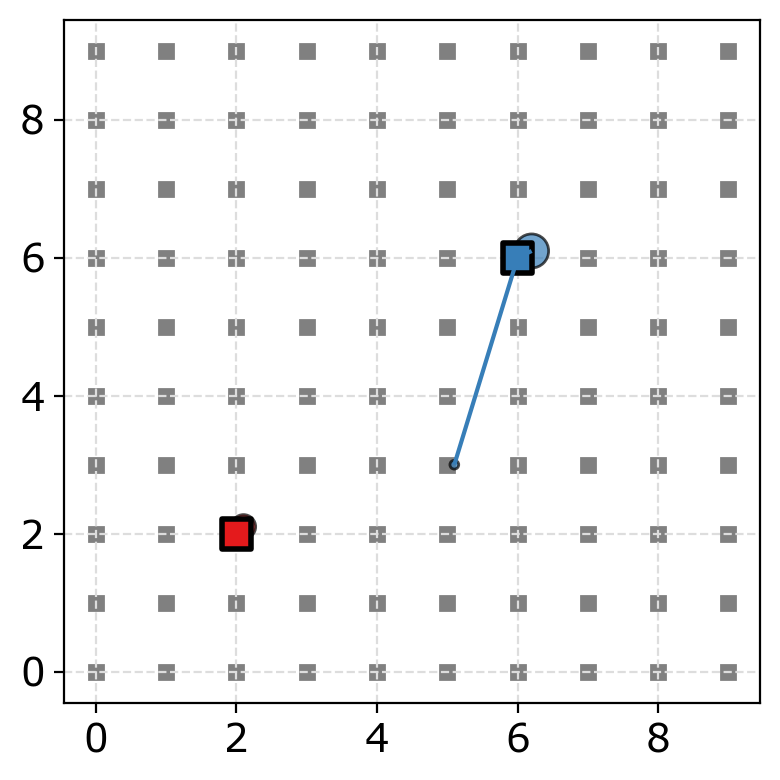

In [ ]:
from crimepy import pmed, geo
from crimepy.query import query_esri
from crimepy.cdcplot import plt
import requests
import pandas as pd

# Setting up default solve
# default solver should often be OK for this problem
# if it takes too long, aggregate to courser areas
if 'GUROBI_CMD' in pmed.av_solv:
    loc_solv = pmed.pulp.GUROBI_CMD
    print('Solver is GUROBI')
elif 'HiGHS' in pmed.av_solv:
    loc_solv = pmed.pulp.HiGHS
    print('Solver is HiGHS')
else:
    print('You will need to figure out what solver you want to use')
    loc_solv = None

# creating simple data to illustrate
# Define crime locations (x, y, count)
crime_locations = [
    (2.1, 2.1, 10),
    (6.2, 6.1, 20),
    (5.1, 3.0, 1)
]

# Define potential drone locations over regular grid
drone_locations = [(i,j) for i in range(10) for j in range(10)]

crime_locations = pd.DataFrame(crime_locations,columns=['x','y','count'])
drone_locations = pd.DataFrame(drone_locations,columns=['x','y'])

# For 2 locations selected, it should choose 1/1 and 6/6 for minsum
selector = pmed.SiteSelection(crime_locations, drone_locations, num_sites=2,problem='minsum')
selector.solve()

fig, ax = plt.subplots(figsize=(4,4))
r1 = ax.plot(drone_locations['x'],drone_locations['y'],'s',markersize=5,color='grey',zorder=-1)
ax = selector.plot_solution(ax=ax,size_range=(10,150)) # squares are sites (colored selected), circles are crimes scaled by counts

Starting to solve function at 2025-09-29 17:48:40.301179
Solve finished at 2025-09-29 17:48:40.351155


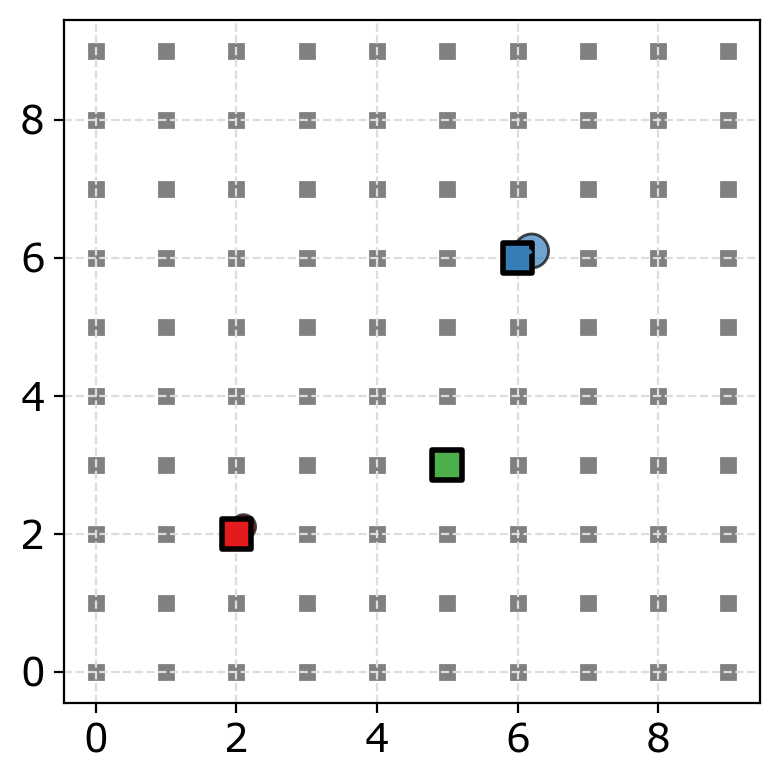

In [2]:
# If you pick 3, it will pick another location just nearby the remaining
selector = pmed.SiteSelection(crime_locations, drone_locations, num_sites=3,problem='minsum')
selector.solve()

fig, ax = plt.subplots(figsize=(4,4))
r1 = ax.plot(drone_locations['x'],drone_locations['y'],'s',markersize=5,color='grey',zorder=-1)
ax = selector.plot_solution(ax=ax,size_range=(10,150)) # squares are sites (colored selected), circles are crimes scaled by counts

Starting to solve function at 2025-09-29 17:48:40.490899
Solve finished at 2025-09-29 17:48:40.575898


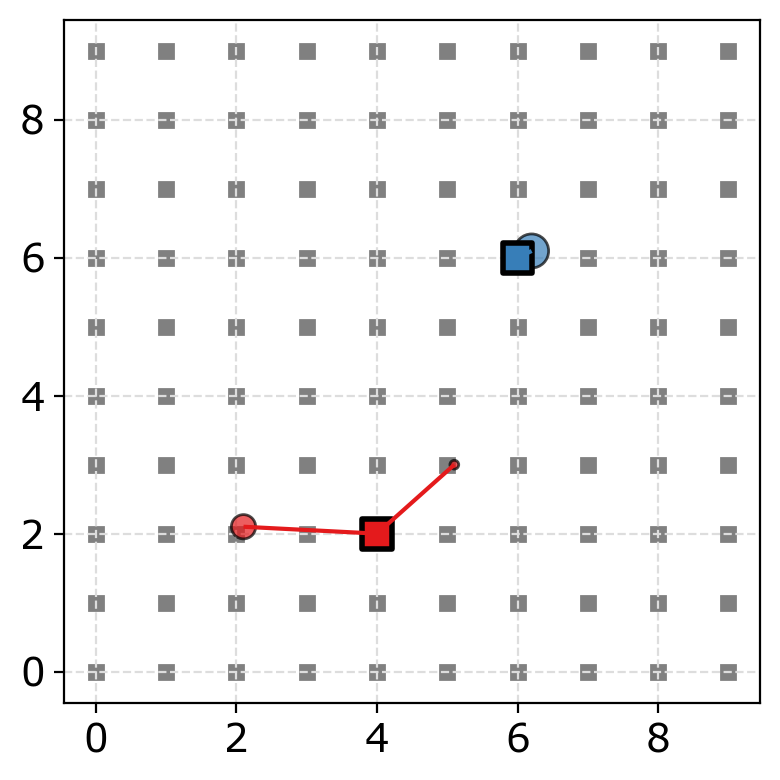

In [3]:
# minimizing the maximum distance travelled will pick different sites
# note here the location with 1 crime changes the result
selector = pmed.SiteSelection(crime_locations, drone_locations, num_sites=2,problem='minmax')
selector.solve(solver=loc_solv()) # cbc will solve this, but a few seconds slower even with tiny problem, highs is instant
fig, ax = plt.subplots(figsize=(4,4))
r1 = ax.plot(drone_locations['x'],drone_locations['y'],'s',markersize=5,color='grey',zorder=-1)
ax = selector.plot_solution(ax=ax,size_range=(10,150)) # squares are sites (colored selected), circles are crimes scaled by counts

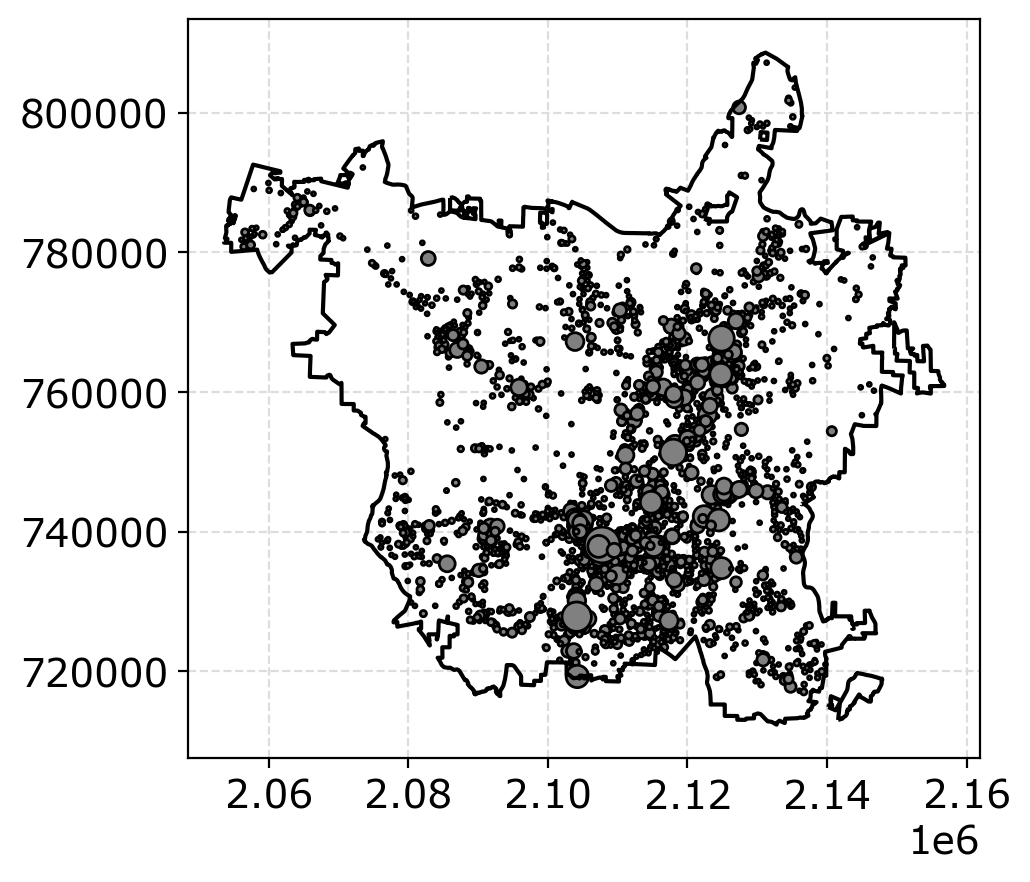

In [4]:
# lets make a more realistic example
# getting serious crimes for Raleigh, aggregated to streets
loc_proj = 'EPSG:2264'
crime_url = 'https://services.arcgis.com/v400IkDOw1ad7Yad/ArcGIS/rest/services/Police_Incidents/FeatureServer/0/query'
cr_kwargs = {'f': 'geojson',
             'outFields': "*",
             'outSR': loc_proj[-4:],
             'where': "reported_block_address NOT IN (' ') AND Crime_Category IN ('WEAPONS VIOLATION','ROBBERY','MURDER')"}

ral_crime = query_esri(crime_url,cr_kwargs)
ral_crime['x'] = ral_crime.geometry.x.round()
ral_crime['y'] = ral_crime.geometry.y.round()
ral_crime = ral_crime[~ral_crime['x'].isna()].reset_index(drop=True)
ral_crime.sort_values(by='case_number',inplace=True,ignore_index=True)
ral_crime['count'] = ral_crime.groupby(['reported_block_address'])['x'].transform(len)

# uses whatever the latest XY coordinate is for the block
ral_crime.drop_duplicates(subset='reported_block_address',keep='last',inplace=True,ignore_index=True)

# only places with more than 1 crime
ral_crime = ral_crime[ral_crime['count'] > 1].reset_index(drop=True)

# now getting the boundary for the city
jur_url = r"https://maps.wakegov.com/arcgis/rest/services/Jurisdictions/Jurisdictions/MapServer/1/query"
jur_par = {'f': 'geojson',
           'outFields': "*",
           'outSR': loc_proj[-4:],
           'where': "JURISDICTION IN ('RALEIGH')"}

ral_bound = query_esri(jur_url,jur_par)

ax = ral_bound.boundary.plot(color='k')
r1 = ax.scatter(ral_crime['x'],ral_crime['y'],s=ral_crime['count'],color='grey',edgecolors='k')


Total number of potential sites 9277


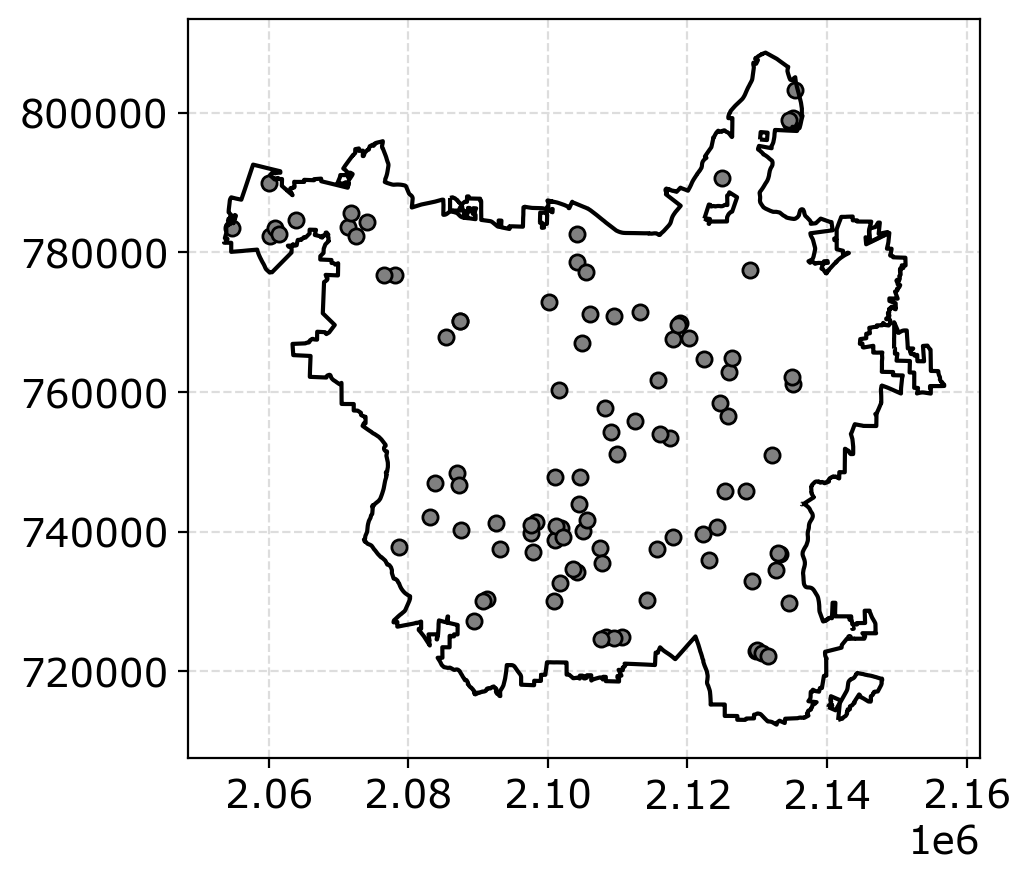

In [ ]:
# Using parking lots as potential locations to site a drone
parking_url = 'https://services.arcgis.com/v400IkDOw1ad7Yad/ArcGIS/rest/services/Parking_Areas/FeatureServer/0/query'
parking_kwargs = {'f': 'geojson',
                  'outFields': "*",
                  'outSR': loc_proj[-4:],
                  'where': "SUBTYPE IN ('GARAGE','PARKING_LOT')"}

parking_lots = query_esri(parking_url,parking_kwargs)
parking_lots['x'] = parking_lots.geometry.centroid.x
parking_lots['y'] = parking_lots.geometry.centroid.y
parking_lots = geo.pip(parking_lots,ral_bound)
print(f'Total number of potential sites {parking_lots.shape[0]}')

# Sampling to go faster, in practice you will want to limit to locations
# you know can actually place as a base (like city owned properties)
parking_lot_sample = parking_lots.sample(100).reset_index(drop=True)

ax = ral_bound.boundary.plot(color='k')
r1 = ax.scatter(parking_lot_sample['x'],parking_lot_sample['y'],s=30,color='grey',edgecolors='k')

Starting to solve function at 2025-09-29 17:49:35.438248
Solve finished at 2025-09-29 17:50:09.552401


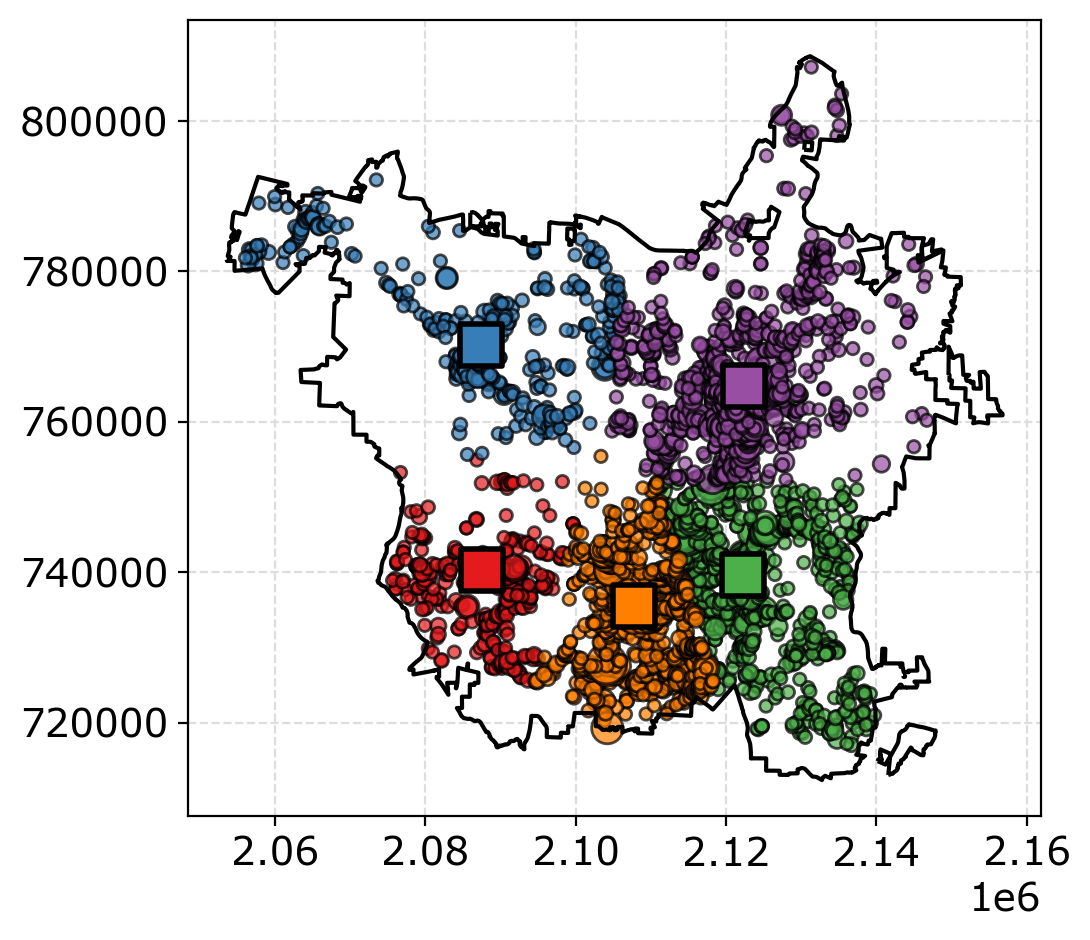

In [ ]:
# minimum sum site locations
ral_selector_5 = pmed.SiteSelection(ral_crime,parking_lot_sample,num_sites=5,problem='minsum',limit_dist=5260*15)
ral_selector_5.solve(solver=loc_solv()) # For my machine, Gurobi ~ 30 seconds, HiGHS ~ 3 minutes

ax = ral_bound.boundary.plot(color='k')
ax = ral_selector_5.plot_solution(ax=ax,lines=False)